<div style="text-align: center; font-weight: bold; font-size: 150%">Projet 4 - Interpreting Transformers Models</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Stéphane CHRETIEN</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>

Ce travail se base sur le notebook [ici](https://colab.research.google.com/drive/1jSYf0pAtLKaErWOz7JZ-U6tyrju6EZTq?usp=sharing).

<div style="text-align: center; font-weight: bold; font-size: 125%">1. Modèle BERT</div><br>

L'apprentissage sur des données de texte a été révolutionné par les transformers. Cela a conduit à l'entraînement de plusieurs modèles qui sont réputés pour être des boîtes noires. L'un de ces modèles est le modèle BERT pour Bidirectionnal Encoder Representations from Transformers. Il s'agit d'un modèle de langue qui a été entraîné à partir d'un masquage statique de texte. De fait on maske certains mots d'un texte et le modèle doit les prédire. Ce modèle a donc tendance à extraire de l'information dans un texte.

Dans ce notebook, l'étude porte sur comment dans un modèle BERT ,les embeddings influencent la prédiction. Pour cela nous avons appliqué le code du notebook original (avec quelques ajustements) à une autre question du SQUAD Dataset.

Le modèle préentrainé utilisé est le modèle 'bert-base-uncased'.

In [ ]:
# install required python packages
!pip install seaborn
!pip install pandas
!pip install matplotlib
!pip install transformers
!pip install captum
#mecab
!apt install aptitude swig
!aptitude install mecab libmecab-dev mecab-ipadic-utf8 git make curl xz-utils file -y
!pip install mecab-python3==0.996.3

#neologd
# !git clone --depth 1 https://github.com/neologd/mecab-ipadic-neologd.git
# !echo yes | mecab-ipadic-neologd/bin/install-mecab-ipadic-neologd -n -a

!pip install transformers
!pip install fugashi==1.1.0 ipadic==1.0.0

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
aptitude is already the newest version (0.8.13-3ubuntu1).
swig is already the newest version (4.0.2-1ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
mecab is already installed at the requested version (0.996-14build9)
libmecab-dev is already installed at the requested version (0.996-14build9)
mecab-ipadic-utf8 is already installed at the requested version (2.7.0-20070801+main-3)
git is already installed at the requested version (1:2.34.1-1ubuntu1.15)
make is already installed at the requested version (4.3-4.1build1)
curl is already installed at the requested version (7.81.0-1ubuntu1.21)
xz-utils is already installed at the requested version (5.2.5-2ubuntu1)
file is already installed at the requested version (1:5.41-3ubuntu0.1)
mecab is already installed at the requested version (0.996-14build9)
libmecab-dev is already installed at the requested version (0.996-14bui

In [ ]:
# import required python libraries
import numpy as np # multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import pandas as pd # data manipulation and analysis
import seaborn as sns # statistical data visualization
import matplotlib.pyplot as plt # object-oriented API for embedding plots

import torch # data structures for multi-dimensional tensors and defines mathematical operations over these tensors
import torch.nn as nn # basic building blocks for graphs
import json

# from transformers import pipeline
from transformers import BertTokenizer, BertForQuestionAnswering, BertConfig # library for transformer models
from captum.attr import visualization as viz # captum visualization tool for matplotlib figure, it visualizes attribution for a given image by normalizing attribution values of the desired sign
from captum.attr import LayerConductance, LayerIntegratedGradients # computes conductance with respect to the given layer and provides integrated gradients augmenting accuracy metrics, model debugging and feature or rule extraction.


In [ ]:
#### Set random seeds for reproducibility
import torch
import random
import numpy as np

seed = 3

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Rend CUDA déterministe (peut ralentir un peu)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
###GPU check
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
#### Load the model and tokenizer
# https://huggingface.co/bert-base-uncased
model_path = 'bert-base-uncased'

# load model
model = BertForQuestionAnswering.from_pretrained(model_path)
model.to(device)
model.eval()
model.zero_grad()

# load tokenizer
tokenizer = BertTokenizer.from_pretrained(model_path)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

<div style="text-align: center; font-weight: bold; font-size: 125%">2. Question-answering: SQUAD Dataset</div><br>

SQUAD (Stanford Question Answering Dataset) sont des questions avec des textes, où les réponses aux questions se trouvent dans le texte. Ce sont des données qui sont utilisées pour fine-tuner des modèles sur des tâches de Question-Answering. Ces données ont la particularité d'avoir été écrites par des humains.

Nous avons expliqué le modèle sur la question et le texte suivants: 

- Question: "Which governing bodies have veto power?"
- Texte: "The European Parliament and the Council of the European Union have powers of amendment and veto during the legislative process."

<div style="text-align: center; font-weight: bold; font-size: 100%">2.1. Pipeline d'apprentissage</div><br>

In [ ]:
### Function to predict the start and end logits for a given input
def predict(inputs, token_type_ids=None, position_ids=None, attention_mask=None):
    output = model(inputs, token_type_ids=token_type_ids,
                 position_ids=position_ids, attention_mask=attention_mask, )
    return output.start_logits, output.end_logits

In [ ]:
### Function to predict the maximum of start and end logits for a given input
def squad_pos_forward_func(inputs, token_type_ids=None, position_ids=None, attention_mask=None, position=0):
    pred = predict(inputs,
                   token_type_ids=token_type_ids,
                   position_ids=position_ids,
                   attention_mask=attention_mask)
    pred = pred[position]
    return pred.max(1).values

In [ ]:
#### Define special token ids
ref_token_id = tokenizer.pad_token_id # A token used for generating token reference
sep_token_id = tokenizer.sep_token_id # A token used as a separator between question and text and it is also added to the end of the text.
cls_token_id = tokenizer.cls_token_id # A token used for prepending to the concatenated question-text word sequence

In [ ]:
#### Function to construct input and reference token id pairs for a given question and text
def construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id):
    question_ids = tokenizer.encode(question, add_special_tokens=False)
    text_ids = tokenizer.encode(text, add_special_tokens=False)

    # construct input token ids
    input_ids = [cls_token_id] + question_ids + [sep_token_id] + text_ids + [sep_token_id]

    # construct reference token ids
    ref_input_ids = [cls_token_id] + [ref_token_id] * len(question_ids) + [sep_token_id] + \
        [ref_token_id] * len(text_ids) + [sep_token_id]

    return torch.tensor([input_ids], device=device), torch.tensor([ref_input_ids], device=device), len(question_ids)

def construct_input_ref_token_type_pair(input_ids, sep_ind=0):
    seq_len = input_ids.size(1)
    token_type_ids = torch.tensor([[0 if i <= sep_ind else 1 for i in range(seq_len)]], device=device)
    ref_token_type_ids = torch.zeros_like(token_type_ids, device=device)# * -1
    return token_type_ids, ref_token_type_ids

def construct_input_ref_pos_id_pair(input_ids):
    seq_length = input_ids.size(1)
    position_ids = torch.arange(seq_length, dtype=torch.long, device=device)
    # we could potentially also use random permutation with `torch.randperm(seq_length, device=device)`
    ref_position_ids = torch.zeros(seq_length, dtype=torch.long, device=device)

    position_ids = position_ids.unsqueeze(0).expand_as(input_ids)
    ref_position_ids = ref_position_ids.unsqueeze(0).expand_as(input_ids)
    return position_ids, ref_position_ids

def construct_attention_mask(input_ids):
    return torch.ones_like(input_ids)

def construct_whole_bert_embeddings(input_ids, ref_input_ids, \
                                    token_type_ids=None, ref_token_type_ids=None, \
                                    position_ids=None, ref_position_ids=None):
    input_embeddings = model.bert.embeddings(input_ids, token_type_ids=token_type_ids, position_ids=position_ids)
    ref_input_embeddings = model.bert.embeddings(ref_input_ids, token_type_ids=ref_token_type_ids, position_ids=ref_position_ids)

    return input_embeddings.to(device), ref_input_embeddings.to(device)

**Définition d'une autre question et d'un texte de la dataset SQUAD.**

In [ ]:
####Question and text for which we want to compute attributions
question, text = "Which governing bodies have veto power?", "The European Parliament and the Council of the European Union have powers of amendment and veto during the legislative process."

Pour construire le BertEmbedding, les vecteurs suivants sont construits:

- input_ids: le sens du mot
- token_type_ids: le mot appartient à la question ou au contexte?
- position_ids: la position du mot dans la concaténation de la question et du contexte.

le BertEmbedding est la somme de ces trois vecteurs.

In [ ]:
#### Construct input and reference token id pairs for the question and text
input_ids, ref_input_ids, sep_id = construct_input_ref_pair(question, text, ref_token_id, sep_token_id, cls_token_id)
token_type_ids, ref_token_type_ids = construct_input_ref_token_type_pair(input_ids, sep_id)
position_ids, ref_position_ids = construct_input_ref_pos_id_pair(input_ids)
attention_mask = construct_attention_mask(input_ids)

indices = input_ids[0].detach().tolist()
all_tokens = tokenizer.convert_ids_to_tokens(indices)

In [ ]:
#### Define the ground truth answer text and compute its start and end token indices in the input token sequence
ground_truth = "The European Parliament and the Council of the European Union."
def find_sublist(sublist, main_list):
    for i in range(len(main_list) - len(sublist) + 1):
        if main_list[i:i+len(sublist)] == sublist:
            return i
    return -1

ground_truth_tokens = tokenizer.encode(
    ground_truth,
    add_special_tokens=False
)

ground_truth_start_ind = find_sublist(ground_truth_tokens[:-1], indices)

if ground_truth_start_ind == -1:
    raise ValueError("Ground truth not found in tokenized context")

ground_truth_end_ind = ground_truth_start_ind + len(ground_truth_tokens) - 1


In [ ]:
start_scores, end_scores = predict(input_ids, \
                                   token_type_ids=token_type_ids, \
                                   position_ids=position_ids, \
                                   attention_mask=attention_mask)


print('Question: ', question)
print('Predicted Answer: ', ' '.join(all_tokens[torch.argmax(start_scores) : torch.argmax(end_scores)+1]))

Question:  Which governing bodies have veto power?
Predicted Answer:  during the legislative process


Là il est clair qu'il s'agit d'une mauvaise réponse. L'interprétation construite à partir de LayerIntegratedGradients va nous permettre d'expliquer comment le modèle est arrivé à cette prédiction.

<div style="text-align: center; font-weight: bold; font-size: 100%">2.2. LayerIntegratedGradients</div><br>



Afin d'analyser les attributions à travers les couches de neurones, la classe utilisée est celle implémentée par Captum appelée LayerIntegratedGradients.

- Dans un premier temps, l'analyse  porte sur les attributions des tokens aux prédictions. Pour analyser l'attribution d'un token, il y a deux options. La première option est d'analyser le BertEmbedding. Dans ce cas, il est difficile de dire quel vecteur d'embedding a vraiment contribué à l'extraction de la réponse. Ce qui amène à la deuxième option, qui est d'analyser les attributions de chaque vecteur d'embedding.
- Ensuite, l'analyse porte sur la fonction principale de LayerIntegratedGradients qui est d'étudier les attributions à travers les couches de neurones.

**LayerIntegratedGradients appliquée sur BertEmbedding**

In [ ]:
### Compute attributions with integrated gradients for the predicted start and end positions
lig = LayerIntegratedGradients(squad_pos_forward_func, model.bert.embeddings)

attributions_start, delta_start = lig.attribute(inputs=input_ids,
                                  baselines=ref_input_ids,
                                  additional_forward_args=(token_type_ids, position_ids, attention_mask, 0),
                                  return_convergence_delta=True)
attributions_end, delta_end = lig.attribute(inputs=input_ids, baselines=ref_input_ids,
                                additional_forward_args=(token_type_ids, position_ids, attention_mask, 1),
                                return_convergence_delta=True)


In [ ]:
#### Function to summarize attributions across embedding dimensions and normalize the attribution scores for visualization
def summarize_attributions(attributions):
    attributions = attributions.sum(dim=-1).squeeze(0)
    attributions = attributions / torch.norm(attributions)
    return attributions

In [ ]:
### Summarize and normalize attributions for the predicted start and end positions
attributions_start_sum = summarize_attributions(attributions_start)
attributions_end_sum = summarize_attributions(attributions_end)

In [ ]:
# storing couple samples in an array for visualization purposes
probs = torch.softmax(start_scores[0], dim=0)
pred_index = torch.argmax(start_scores[0])

start_position_vis = viz.VisualizationDataRecord(
    attributions_start_sum,
    probs[pred_index],
    pred_index,
    ground_truth_start_ind,
    ground_truth,
    attributions_start_sum.sum(),
    all_tokens,
    delta_start
)

probs = torch.softmax(end_scores[0], dim=0)
pred_index = torch.argmax(end_scores[0])

end_position_vis = viz.VisualizationDataRecord(
    attributions_end_sum,
    probs[pred_index],
    pred_index,
    ground_truth_end_ind,
    ground_truth,
    attributions_end_sum.sum(),
    all_tokens,
    delta_start
)

print('\033[1m', 'Visualizations For Start Position', '\033[0m')
viz.visualize_text([start_position_vis])

print('\033[1m', 'Visualizations For End Position', '\033[0m')
viz.visualize_text([end_position_vis])

 Visualizations For Start Position 


 Visualizations For End Position 


Pour la "start position" les tokesn '?(7)' et 'the(9)' poussent le modèle à choisir  'during(25)' comme "start position".  

Pour l' "end position", le token 'process(28)' a une attribution très forte à la prédiction.

**LayerIntegratedGradients appliquée sur chaque vecteur d'embedding**

In [ ]:
#### Compute attributions with integrated gradients for the predicted start and end positions with respect to the word embeddings, token type embeddings and position embeddings separately
lig2 = LayerIntegratedGradients(squad_pos_forward_func, \
                                [model.bert.embeddings.word_embeddings, \
                                 model.bert.embeddings.token_type_embeddings, \
                                 model.bert.embeddings.position_embeddings])

attributions_start = lig2.attribute(inputs=(input_ids, token_type_ids, position_ids),
                                  baselines=(ref_input_ids, ref_token_type_ids, ref_position_ids),
                                  additional_forward_args=(attention_mask, 0))
attributions_end = lig2.attribute(inputs=(input_ids, token_type_ids, position_ids),
                                  baselines=(ref_input_ids, ref_token_type_ids, ref_position_ids),
                                  additional_forward_args=(attention_mask, 1))

attributions_start_word = summarize_attributions(attributions_start[0])
attributions_end_word = summarize_attributions(attributions_end[0])

attributions_start_token_type = summarize_attributions(attributions_start[1])
attributions_end_token_type = summarize_attributions(attributions_end[1])

attributions_start_position = summarize_attributions(attributions_start[2])
attributions_end_position = summarize_attributions(attributions_end[2])

/tmp/ipython-input-2288312784.py:2: UserWarning: Multiple layers provided. Please ensure that each layer is**not** solely dependent on the outputs ofanother layer. Please refer to the documentation for moredetail.
  lig2 = LayerIntegratedGradients(squad_pos_forward_func, \


In [ ]:
#### Function to get top k attributed tokens for a given attribution score tensor
def get_topk_attributed_tokens(attrs, k=5):
    values, indices = torch.topk(attrs, k)
    top_tokens = [all_tokens[idx] for idx in indices]
    return top_tokens, values, indices

In [ ]:
#### Get top k attributed tokens for the predicted start and end positions with respect to the word embeddings, token type embeddings and position embeddings separately
top_words_start, top_words_val_start, top_word_ind_start = get_topk_attributed_tokens(attributions_start_word)
top_words_end, top_words_val_end, top_words_ind_end = get_topk_attributed_tokens(attributions_end_word)

top_token_type_start, top_token_type_val_start, top_token_type_ind_start = get_topk_attributed_tokens(attributions_start_token_type)
top_token_type_end, top_token_type_val_end, top_token_type_ind_end = get_topk_attributed_tokens(attributions_end_token_type)

top_pos_start, top_pos_val_start, pos_ind_start = get_topk_attributed_tokens(attributions_start_position)
top_pos_end, top_pos_val_end, pos_ind_end = get_topk_attributed_tokens(attributions_end_position)

df_start = pd.DataFrame({'Word(Index), Attribution': ["{} ({}), {}".format(word, pos, round(val.item(),2)) for word, pos, val in zip(top_words_start, top_word_ind_start, top_words_val_start)],
                   'Token Type(Index), Attribution': ["{} ({}), {}".format(ttype, pos, round(val.item(),2)) for ttype, pos, val in zip(top_token_type_start, top_token_type_ind_start, top_words_val_start)],
                   'Position(Index), Attribution': ["{} ({}), {}".format(position, pos, round(val.item(),2)) for position, pos, val in zip(top_pos_start, pos_ind_start, top_pos_val_start)]})
df_start.style.apply(['cell_ids: False'])

df_end = pd.DataFrame({'Word(Index), Attribution': ["{} ({}), {}".format(word, pos, round(val.item(),2)) for word, pos, val in zip(top_words_end, top_words_ind_end, top_words_val_end)],
                   'Token Type(Index), Attribution': ["{} ({}), {}".format(ttype, pos, round(val.item(),2)) for ttype, pos, val in zip(top_token_type_end, top_token_type_ind_end, top_words_val_end)],
                   'Position(Index), Attribution': ["{} ({}), {}".format(position, pos, round(val.item(),2)) for position, pos, val in zip(top_pos_end, pos_ind_end, top_pos_val_end)]})
df_end.style.apply(['cell_ids: False'])

['{}({})'.format(token, str(i)) for i, token in enumerate(all_tokens)]

['[CLS](0)',
 'which(1)',
 'governing(2)',
 'bodies(3)',
 'have(4)',
 'veto(5)',
 'power(6)',
 '?(7)',
 '[SEP](8)',
 'the(9)',
 'european(10)',
 'parliament(11)',
 'and(12)',
 'the(13)',
 'council(14)',
 'of(15)',
 'the(16)',
 'european(17)',
 'union(18)',
 'have(19)',
 'powers(20)',
 'of(21)',
 'amendment(22)',
 'and(23)',
 'veto(24)',
 'during(25)',
 'the(26)',
 'legislative(27)',
 'process(28)',
 '.(29)',
 '[SEP](30)']

In [ ]:
####Display top attributed tokens for the predicted start position
df_start

,"Word(Index), Attribution","Token Type(Index), Attribution","Position(Index), Attribution"
0,"parliament (11), 0.27","during (25), 0.27","during (25), 0.69"
1,"council (14), 0.19","the (26), 0.19","the (26), 0.3"
2,"veto (5), 0.19","the (9), 0.19","powers (20), 0.27"
3,"european (10), 0.17","the (13), 0.17","power (6), 0.24"
4,"legislative (27), 0.17","the (16), 0.17","the (13), 0.21"


In [ ]:
#####Display top attributed tokens for the predicted end position
df_end

,"Word(Index), Attribution","Token Type(Index), Attribution","Position(Index), Attribution"
0,". (29), 0.52","european (10), 0.52","european (17), 0.36"
1,"and (12), 0.34","european (17), 0.34","european (10), 0.36"
2,"and (23), 0.28","parliament (11), 0.28","parliament (11), 0.24"
3,"? (7), 0.07","during (25), 0.07","amendment (22), 0.23"
4,"have (4), 0.05","and (12), 0.05","union (18), 0.22"


Les deux dataframes affichés montrent en détail comment chaque vecteur d'embedding a contribué à la prédiction de la "start position" et de la "end position". Cependant, la méthode de LayerIntegratedGradients appliquée sur chaque vecteur d'embedding n'est pas facile à lire, ni à interpréter comme dans le cas de la méthode de LayerIntegratedGradients appliquée au vecteur de BertEmbeddings.

**Layer conductance**

In [ ]:
def squad_pos_forward_func2(input_emb, attention_mask=None, position=0):
    pred = model(inputs_embeds=input_emb, attention_mask=attention_mask, )
    pred = pred[position]
    return pred.max(1).values

In [ ]:
layer_attrs_start = []
layer_attrs_end = []

# The token that we would like to examine separately.
token_to_explain = 5 # the index of the token that we would like to examine more thoroughly
layer_attrs_start_dist = []
layer_attrs_end_dist = []

input_embeddings, ref_input_embeddings = construct_whole_bert_embeddings(input_ids, ref_input_ids, \
                                         token_type_ids=token_type_ids, ref_token_type_ids=ref_token_type_ids, \
                                         position_ids=position_ids, ref_position_ids=ref_position_ids)

for i in range(model.config.num_hidden_layers):
    lc = LayerConductance(squad_pos_forward_func2, model.bert.encoder.layer[i])
    layer_attributions_start = lc.attribute(inputs=input_embeddings, baselines=ref_input_embeddings, additional_forward_args=(attention_mask, 0))
    layer_attributions_end = lc.attribute(inputs=input_embeddings, baselines=ref_input_embeddings, additional_forward_args=(attention_mask, 1))
    layer_attrs_start.append(summarize_attributions(layer_attributions_start).cpu().detach().tolist())
    layer_attrs_end.append(summarize_attributions(layer_attributions_end).cpu().detach().tolist())

    # storing attributions of the token id that we would like to examine in more detail in token_to_explain
    layer_attrs_start_dist.append(layer_attributions_start[0,token_to_explain,:].cpu().detach().tolist())
    layer_attrs_end_dist.append(layer_attributions_end[0,token_to_explain,:].cpu().detach().tolist())

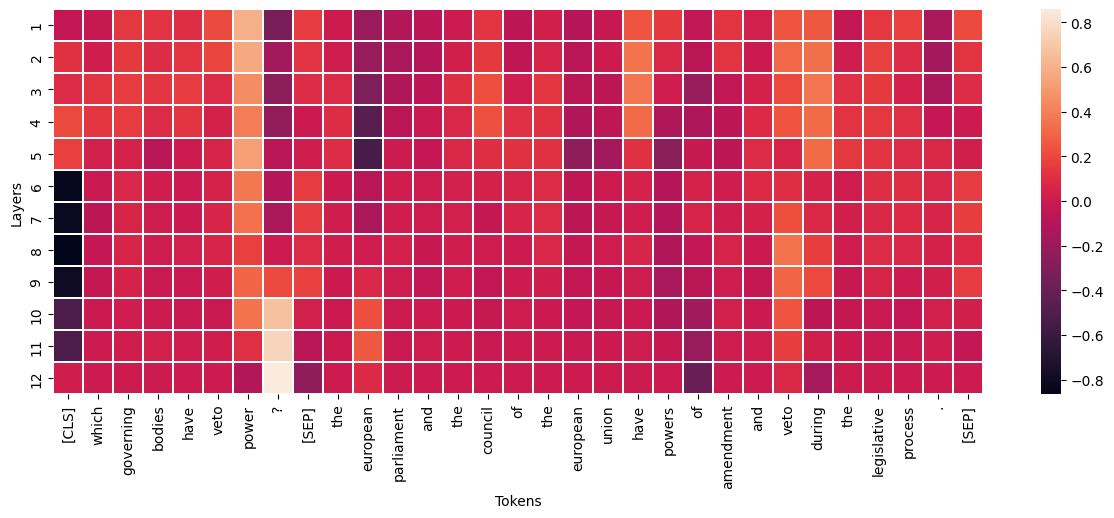

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))
xticklabels=all_tokens
yticklabels=list(range(1,13))
ax = sns.heatmap(np.array(layer_attrs_start), xticklabels=xticklabels, yticklabels=yticklabels, linewidth=0.2)
plt.xlabel('Tokens')
plt.ylabel('Layers')
plt.show()

Dans les premières couches le token '? (7)' repoussent le modèle dans la prédiction de la position de début. Mais dans les dernières couches, il a une attribution positive assez forte. Donc il est très intéressant d'analyser les attributions à travers les couches afin de voir dans quelles couches le modèle prédit les tokens de début et de fin.

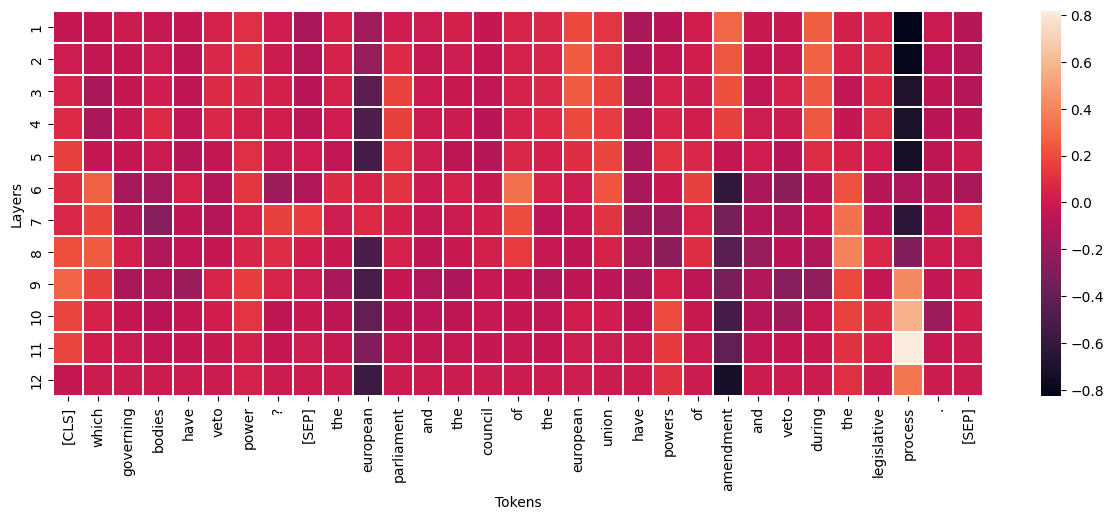

In [ ]:
fig, ax = plt.subplots(figsize=(15,5))

xticklabels=all_tokens
yticklabels=list(range(1,13))
ax = sns.heatmap(np.array(layer_attrs_end), xticklabels=xticklabels, yticklabels=yticklabels, linewidth=0.2) #, annot=True
plt.xlabel('Tokens')
plt.ylabel('Layers')

plt.show()

Le même pattern que pour la position start se répète avec le token 'process(28)'. En effet, dans les premières couches il repousse le modèle, mais dans les dernières couches il contribue positivement à la prédiction.

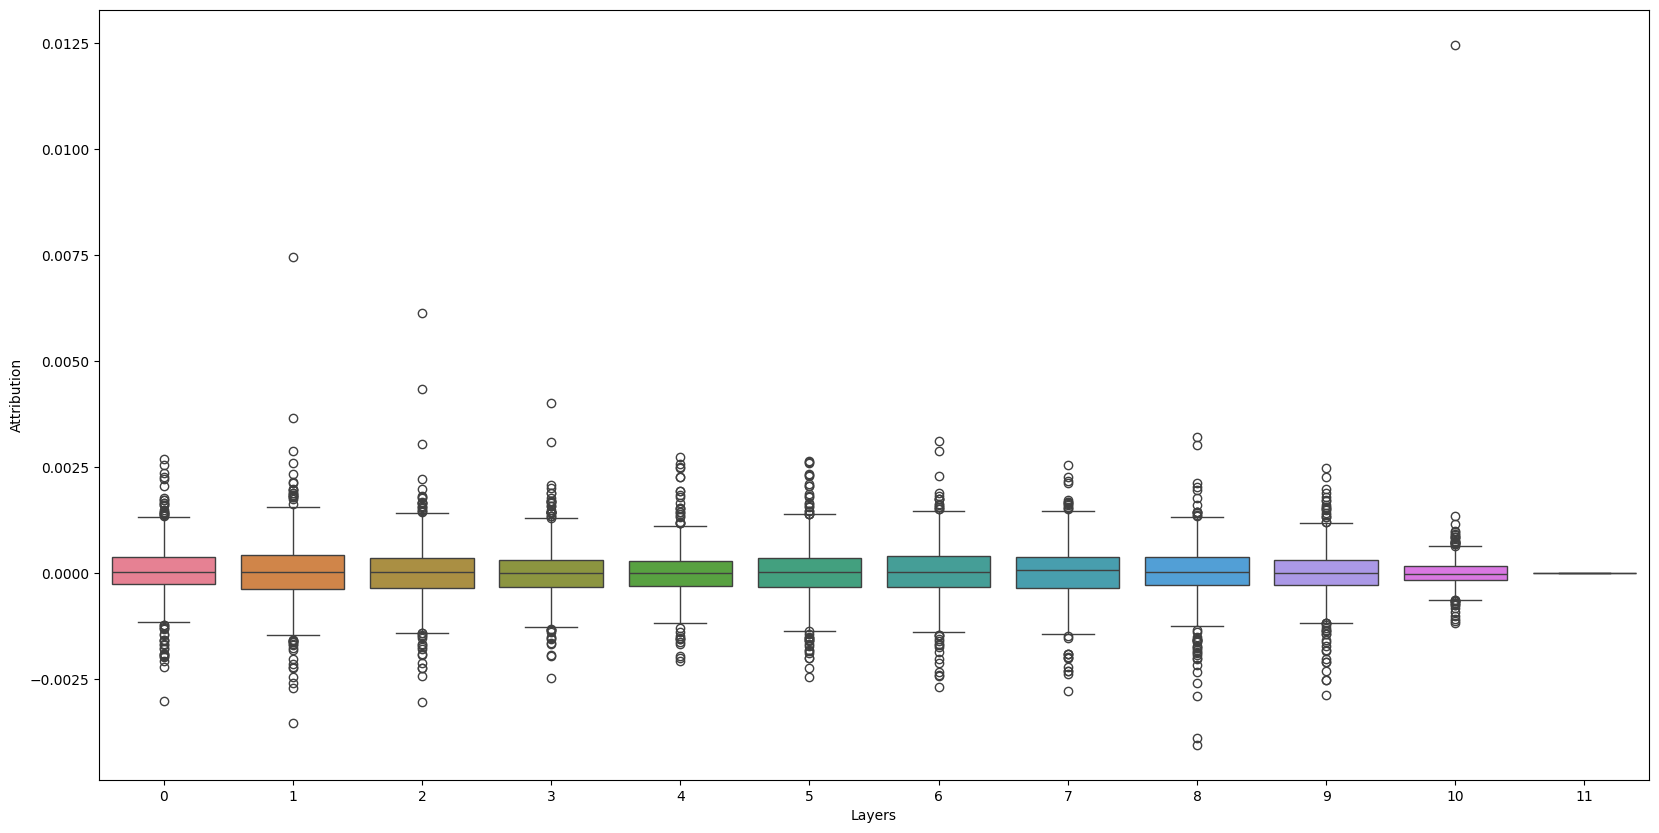

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))
ax = sns.boxplot(data=layer_attrs_start_dist)
plt.xlabel('Layers')
plt.ylabel('Attribution')
plt.show()

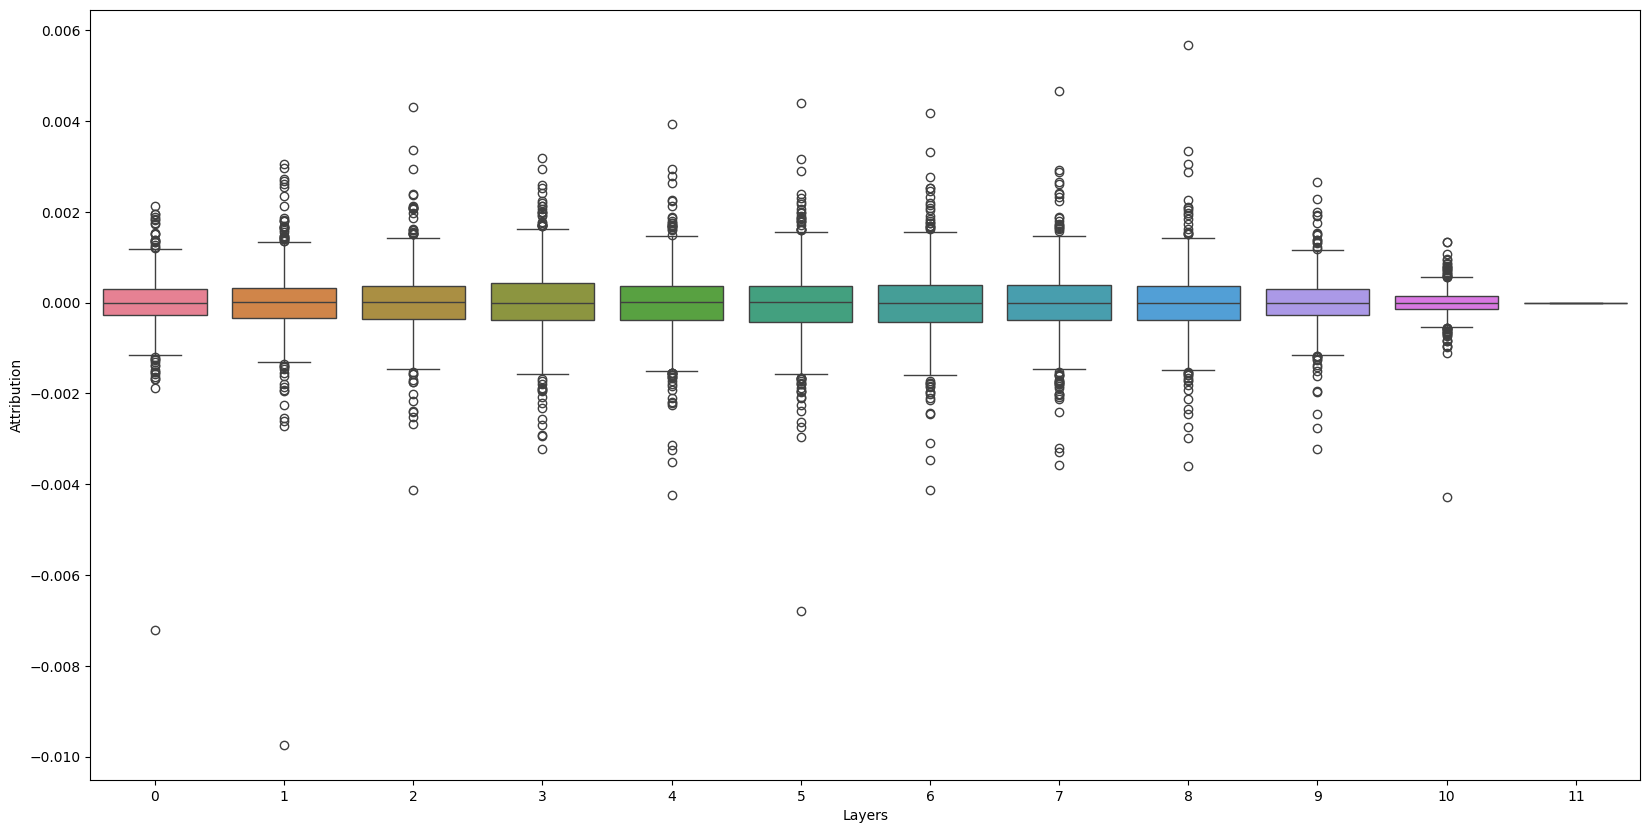

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))
ax = sns.boxplot(data=layer_attrs_end_dist)
plt.xlabel('Layers')
plt.ylabel('Attribution')
plt.show()

La représentation en boxplot, nous permet de repérer rapidement les tokens qui sont des outliers. Ce sont les tokens qui influencent plus la prédiction.

In [ ]:
def pdf_attr(attrs, bins=100):
    return np.histogram(attrs, bins=bins, density=True)[0]

In [ ]:
layer_attrs_end_pdf = map(lambda layer_attrs_end_dist: pdf_attr(layer_attrs_end_dist), layer_attrs_end_dist)
layer_attrs_end_pdf = np.array(list(layer_attrs_end_pdf))

# summing attribution along embedding diemension for each layer
# size: #layers
attr_sum = np.array(layer_attrs_end_dist).sum(-1)

# size: #layers
layer_attrs_end_pdf_norm = np.linalg.norm(layer_attrs_end_pdf, axis=-1, ord=1)

#size: #bins x #layers
layer_attrs_end_pdf = np.transpose(layer_attrs_end_pdf)

#size: #bins x #layers
layer_attrs_end_pdf = np.divide(layer_attrs_end_pdf, layer_attrs_end_pdf_norm, where=layer_attrs_end_pdf_norm!=0)

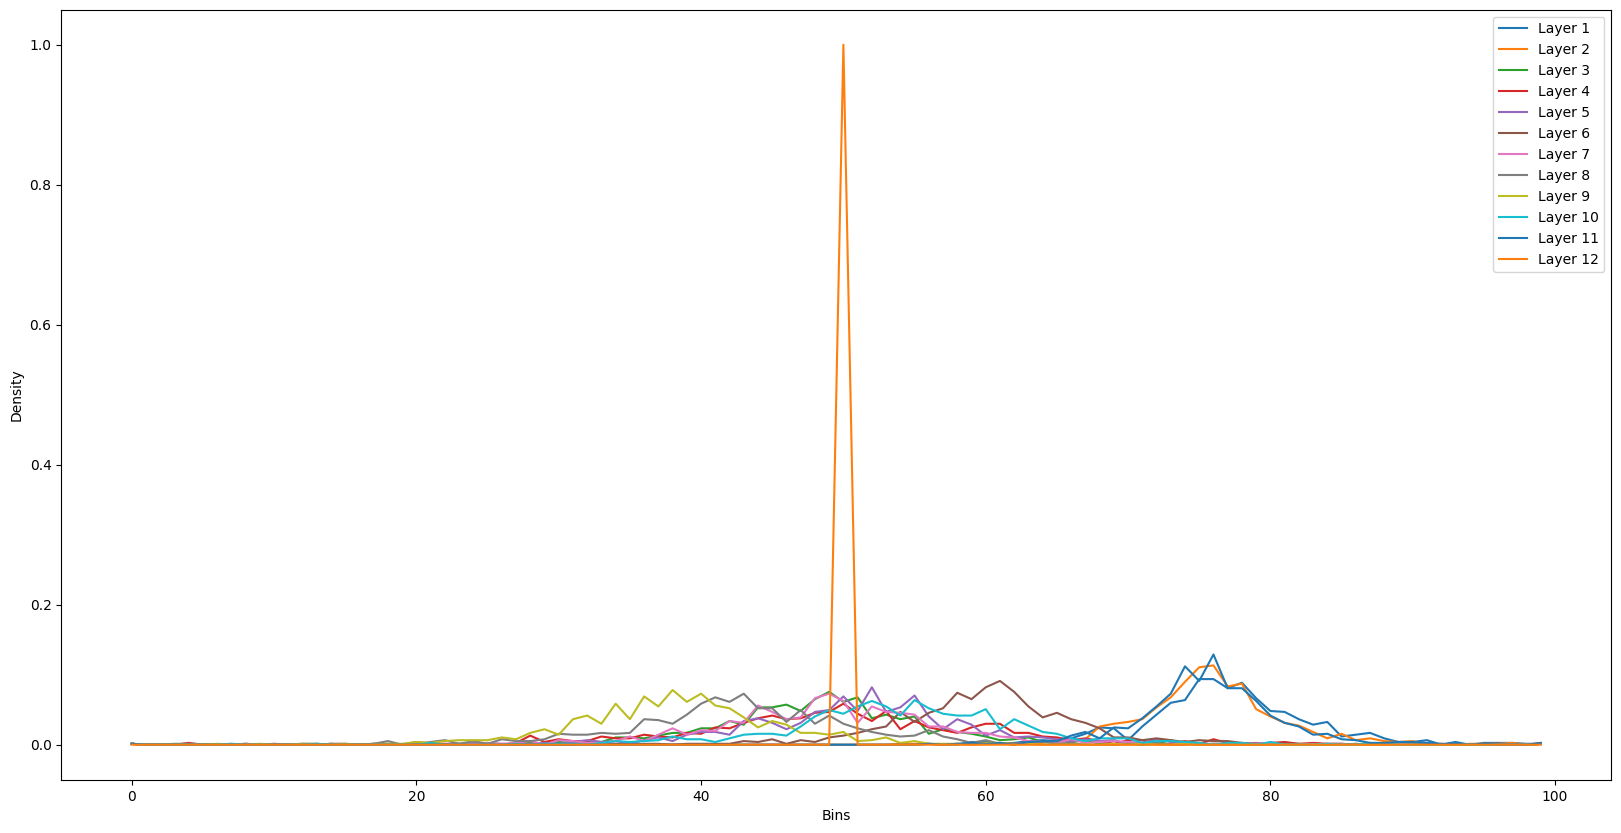

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))
plt.plot(layer_attrs_end_pdf)
plt.xlabel('Bins')
plt.ylabel('Density')
plt.legend(['Layer '+ str(i) for i in range(1,13)])
plt.show()

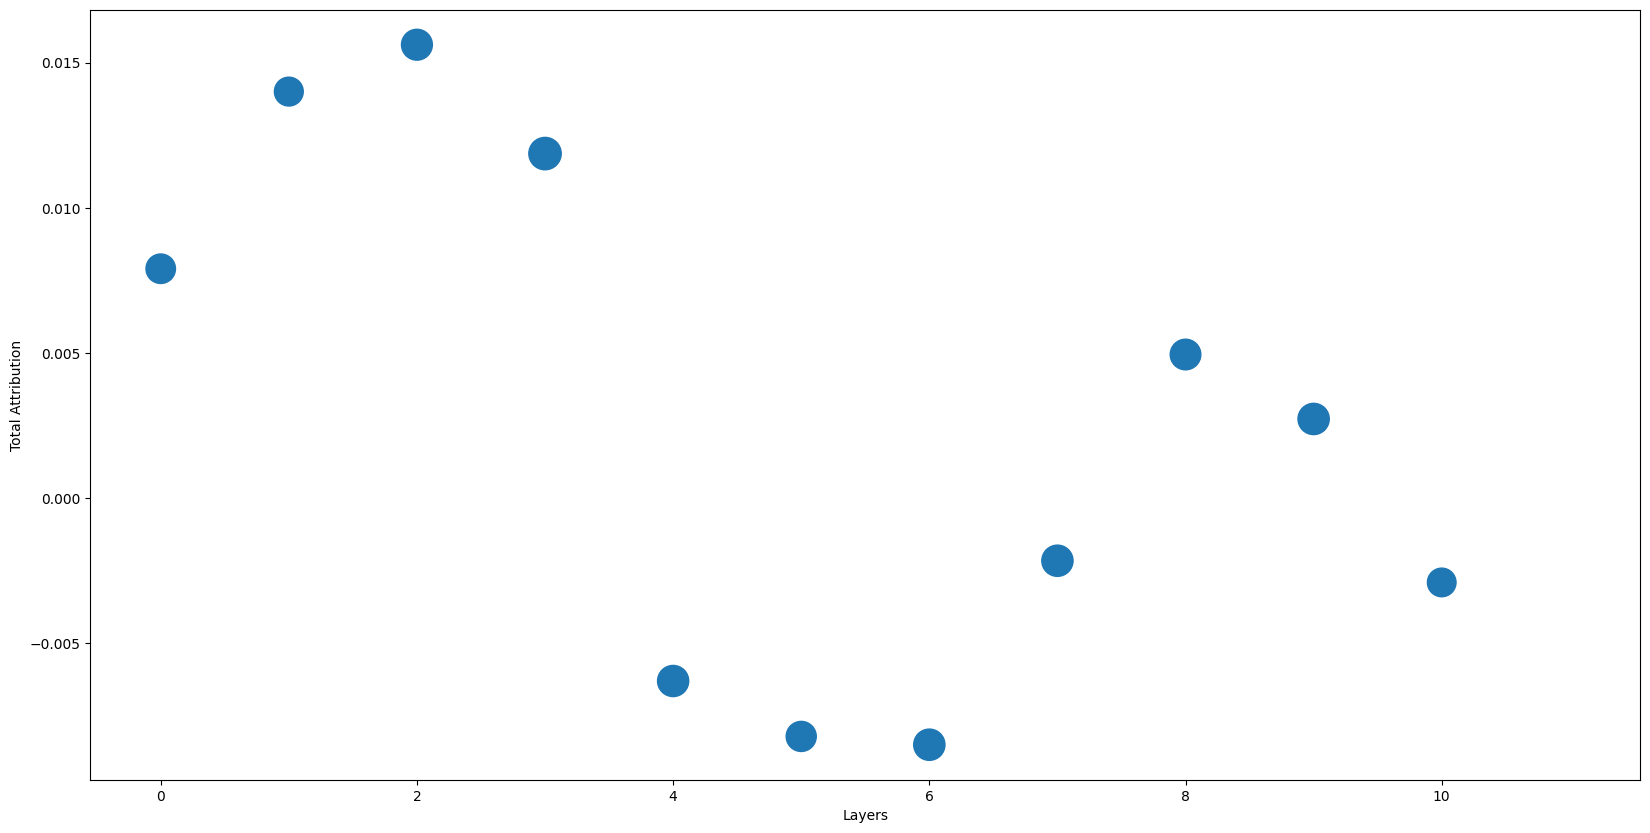

In [ ]:
fig, ax = plt.subplots(figsize=(20,10))

# replacing 0s with 1s. np.log(1) = 0 and np.log(0) = -inf
layer_attrs_end_pdf[layer_attrs_end_pdf == 0] = 1
layer_attrs_end_pdf_log = np.log2(layer_attrs_end_pdf)

# size: #layers
entropies= -(layer_attrs_end_pdf * layer_attrs_end_pdf_log).sum(0)

plt.scatter(np.arange(12), attr_sum, s=entropies * 100)
plt.xlabel('Layers')
plt.ylabel('Total Attribution')
plt.show()

Avec ce graphe, nous pouvons déterminer les couches qui sont très décisisves. Pour le modèle BERT, les premières couches sont très décisives.

**Conclusion :**

Au terme de ce mini-projet nous pouvons relever les points suivants:



*   La méthode LayerIntegratedGradients est un bon moyen d'analyser la prédiction d'un modèle de deep learning. Dans ce contexte particulier de texte, elle nous permet de déterminer les tokens qui influencent le modèle BERT dans l'extraction de texte. Cela nous permet de déterminer si le modèle sait extraire les réponses en se basant sur les bonnes notions.
*   D'autre part, l'étude à travers les couches du réseau nous permet de déterminer les couches décisives et aussi d'analyser le raisonnement progressif du réseau.

Dans cet exemple particulier, il est évident que le modèle ne met pas l'accent sur les bons tokens qui peuvent l'aider à déterminer la bonne réponse. Dans l'embedding, les tokens comme 'governing', 'bodies', 'veto', 'power', 'powers', 'parliament et 'council' auraient dû avoir des attributions élevées, mais la plupart était neutre. Le modèle nécessite donc un bon fine-tuning pour améliorer sa performance.
